# Sieci neuronowe i algorytmy genetyczne - projekt 2026
Temat: Linear Neural Networks for Regression

Celem projektu jest wykorzystanie regresji liniowej do rozwiązania realnego problemu - w tym wypadku jest to estymacja kosztu domów w Kalifornii.

Na początku należy zaimportować wszystkie niezbędne moduły - w tym wypadku będą to ```pandas```, ```numpy```, ```matplotlib``` oraz ```seaborn```.

Następnie wczytać dane - można je również wyświetlić.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
data = pd.read_csv("Data/housing.csv")

In [28]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


# Wstępna analiza danych
Pierwszym etapem jest odpowiednie zrozumienie i przetworzenie danych wejściowych w taki sposób, aby w późniejszym etapie model mógł sobie łatwo i bez przekłamywania poradzić sobie z ich interpretacją.

Czynnością od której można zacząć jest po prostu wyświetlnie podstawowych informacji o wczytanych danych.

In [55]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


Jak widać w kolumnie ```total_bedrooms``` widać, że jest mniej wartości Non-Null - co oznacza, że trzeba te wartości albo sztucznie dodać do tej jednej konkretnej kolumny, albo usunąć z innych tyle żeby w ostateczności we wszytkich było ty wartości tyle samo.

Na początek można zobaczyć ile konkretnie jest tych wierszy z wartościami zerowymi.

In [59]:
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Teraz, aby zyskać szerszą perspektywę można zobaczyć jaki procent z całości stanowią te wartości zerowe.

In [60]:
data.isna().mean() * 100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

Jak widać jest to bardzo marginalna wartość w okolicy jednego procenta.

Nie zmienia to jednak faktu, że te wartości zerowe mogą korelować z wartością, która będzie docelowo oszacowywana - w związku z tym należy sprawdzić jak ma się średnia cena domu zapisana dla rzędów z taka wartością zerową do rzędów bez takiej wartości.

In [62]:
data.groupby(data["total_bedrooms"].isna())["median_house_value"].mean()

total_bedrooms
False    206864.413155
True     206007.280193
Name: median_house_value, dtype: float64

Ceny są zbliżone do siebie, a więc nie jest to istotna cecha - z racji, że tych wartości jest bardzo mało można dostosować inne kolumny poprzez ich nieznaczne zmniejszenie.

In [32]:
data_cleared = data.dropna()

In [33]:
data_cleared.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


# Podział danych na treningowe oraz testowe
Z odpowiednią przygotowanymi danymi można przystąpić do ich podziału na dane treningowe oraz testowe.

Dane zostaną podzielone w proporcji 8:2, czyli 80% będzie przydzielone jako dane treningowe, a pozostałe 20% jako dane testowe.

In [34]:
from sklearn.model_selection import train_test_split

X = data_cleared.drop(["median_house_value"], axis=1)
Y = data_cleared["median_house_value"]

In [35]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [36]:
train_data = X_train.join(Y_train)

In [37]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
2487,-120.35,36.16,18.0,1519.0,296.0,846.0,272.0,2.7792,INLAND,85300.0
5988,-117.72,34.10,32.0,3241.0,895.0,1592.0,810.0,2.4952,INLAND,181800.0
8245,-118.19,33.78,31.0,1648.0,484.0,898.0,457.0,1.5844,NEAR OCEAN,162500.0
18471,-121.64,37.14,14.0,5487.0,1024.0,2823.0,979.0,4.1750,<1H OCEAN,229800.0
19379,-120.87,37.77,9.0,4838.0,920.0,2460.0,923.0,3.5959,INLAND,142700.0
...,...,...,...,...,...,...,...,...,...,...
13973,-116.82,34.24,11.0,5799.0,1527.0,713.0,262.0,2.5147,INLAND,84700.0
1404,-122.07,37.96,37.0,1217.0,199.0,552.0,194.0,5.0445,NEAR BAY,196200.0
2107,-119.74,36.74,39.0,4893.0,1210.0,4749.0,1067.0,1.2065,INLAND,55600.0
16379,-121.30,38.02,16.0,2717.0,621.0,3343.0,643.0,2.5473,INLAND,106300.0


# Eksploracja danych treningowych
Na podstawie odpowiednio podzielonych danych można je dalej rozważać - w tym celu przyda się wyświetlenie wartości każdej cechy w formie histogramu oraz mapy ciepła.

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

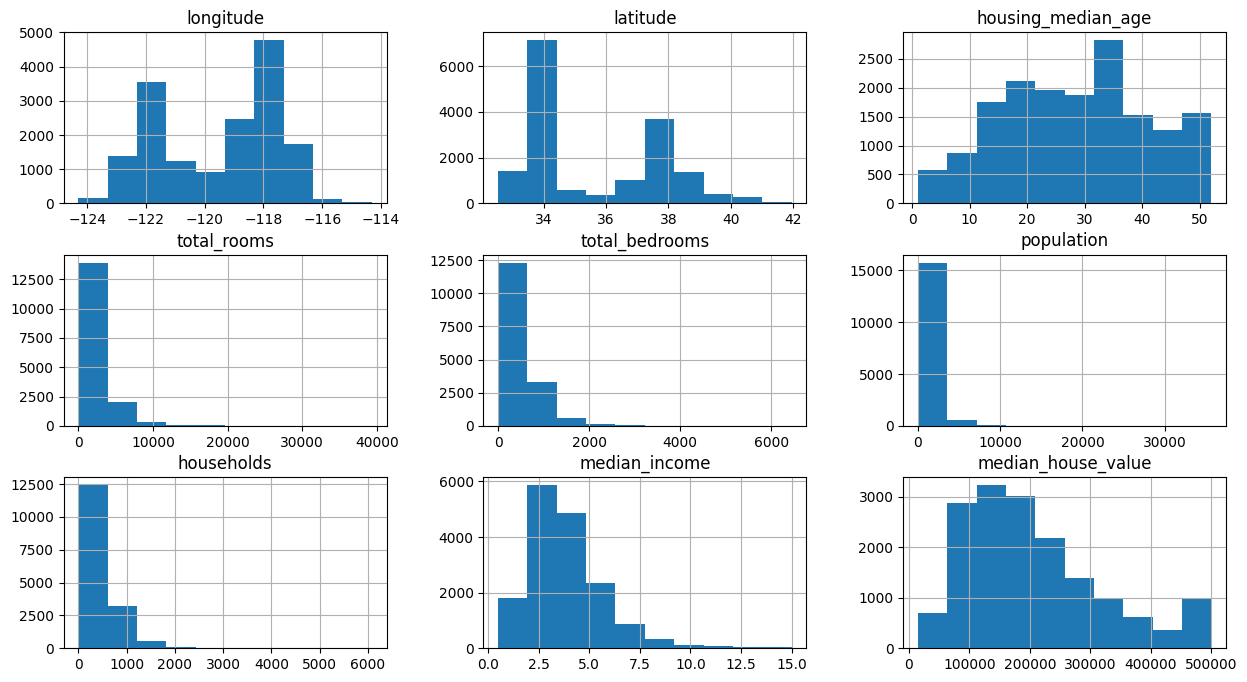

In [38]:
train_data.hist(figsize=(15,8))

<Axes: >

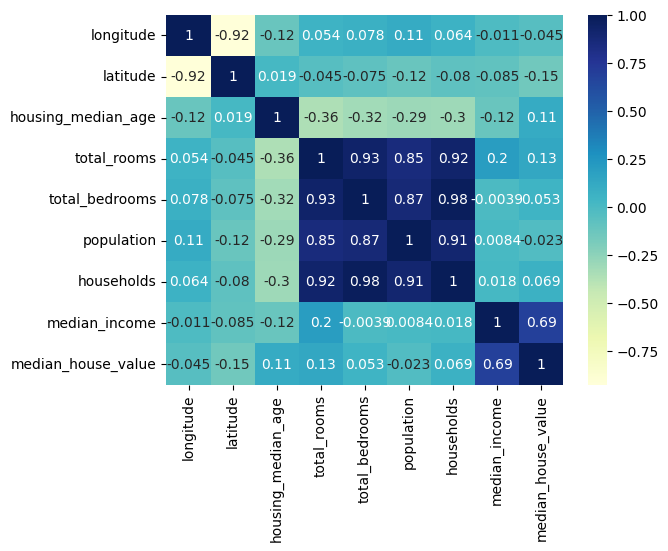

In [39]:
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

Na podstawie powyższych wykresów, a zwłaszcza histogramów można zwrócić uwagę na jeden problem - część cech ma rozkład daleki od idealnego; są one wyraźnie prawostronnie skośne, czyli ich "ogon" ciągnie się od lewej strony do prawej. Taki stan rzeczy może by problematyczny dla poźniejszej ewaluacji wyników. Żeby sobie z tym poradzić można skorzystać z wbudownej do ```numpy``` funkcji ```log1p```, która bierze logarytm naturalny z podanej kolumny i dodaje do niego 1 eliminując w ten sposób możliwość wystąpnia przypadku, iż zostanie obliczony logarytm z 0. 

In [40]:
train_data["total_rooms"] = np.log1p(train_data["total_rooms"])
train_data["total_bedrooms"] = np.log1p(train_data["total_bedrooms"])
train_data["population"] = np.log1p(train_data["population"])
train_data["households"] = np.log1p(train_data["households"])

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

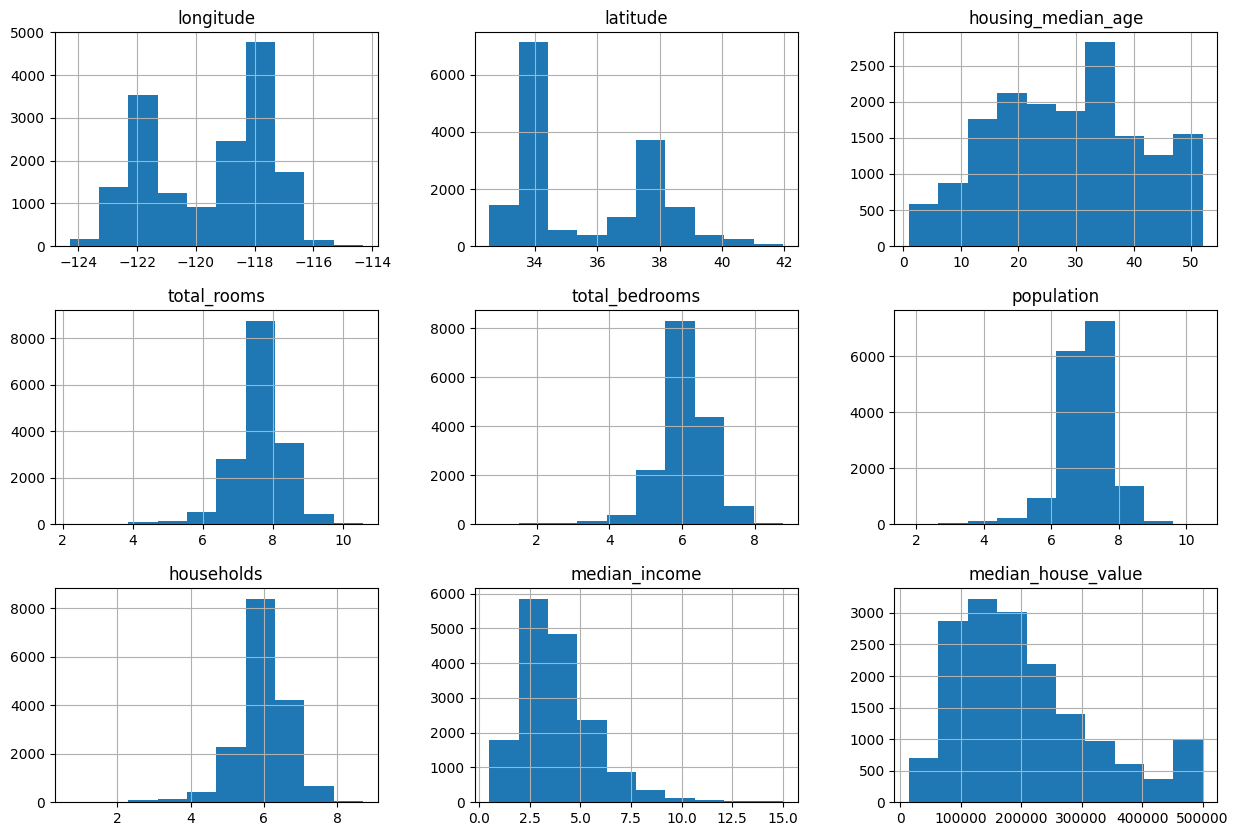

In [41]:
train_data.hist(figsize=(15,10))

Teraz rozkład w tych kolumnach jest zdecydowanie bardziej zbliżony do idealnego.

Następnie należy zająć się kolumną ```ocean_proximity```, ponieważ jest to cecha, która składa się z wyrazów można rozdzielić każda z kilku pojawiających się wartości na osobną kolumnę i przydzielić jej wartość 0 lub 1 w zależności czy jest prawdziwa czy nie. W ten sposób dane zostaną poprawnie zbinaryzowane.

In [42]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop(["ocean_proximity"], axis=1)

<Axes: >

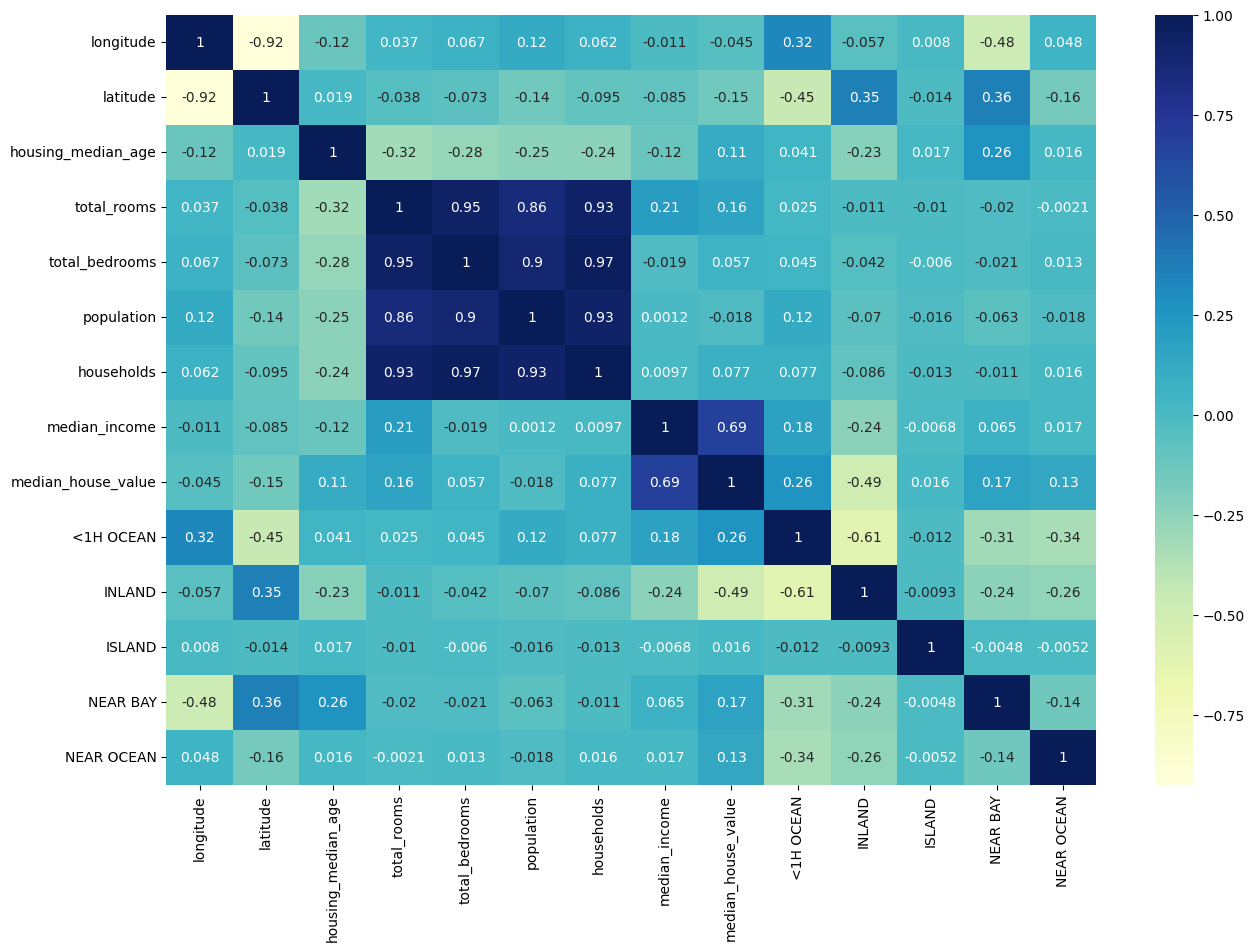

In [45]:
plt.figure(figsize=(15,10))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

W ten sposób na mapie ciepła można zobaczyć wyraźną korelację pomiędzy cechą np. ```<1H OCEAN```, a ```median_house_value```. Ponadto dla jeszcze lepszej wizualizacji można stworzyć wykres rozrzutu lokalizacji względem ceny domu.

<Axes: xlabel='latitude', ylabel='longitude'>

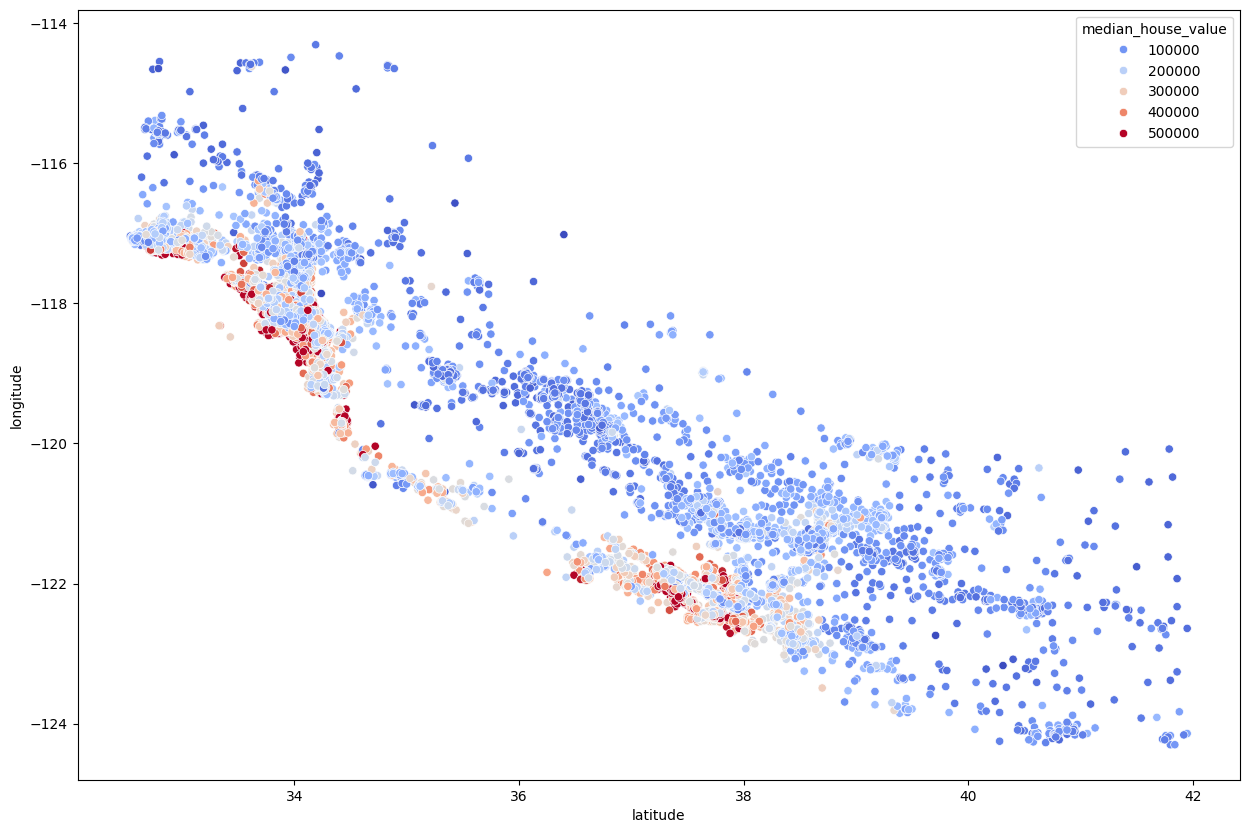

In [46]:
plt.figure(figsize=(15,10))
sns.scatterplot(x="latitude", y="longitude", data=train_data, hue="median_house_value", palette="coolwarm")

Jeszcze jedną interesującą charakterystyką może być stosunek ilości sypialni do całkowitej ilości pokoi w domu oraz ilość pokoi wobec całkowitej ilości domów.

In [47]:
train_data["bedroom_ratio"] = train_data["total_bedrooms"] / train_data["total_rooms"]
train_data["household_rooms"] = train_data["total_rooms"] / train_data["households"]

<Axes: >

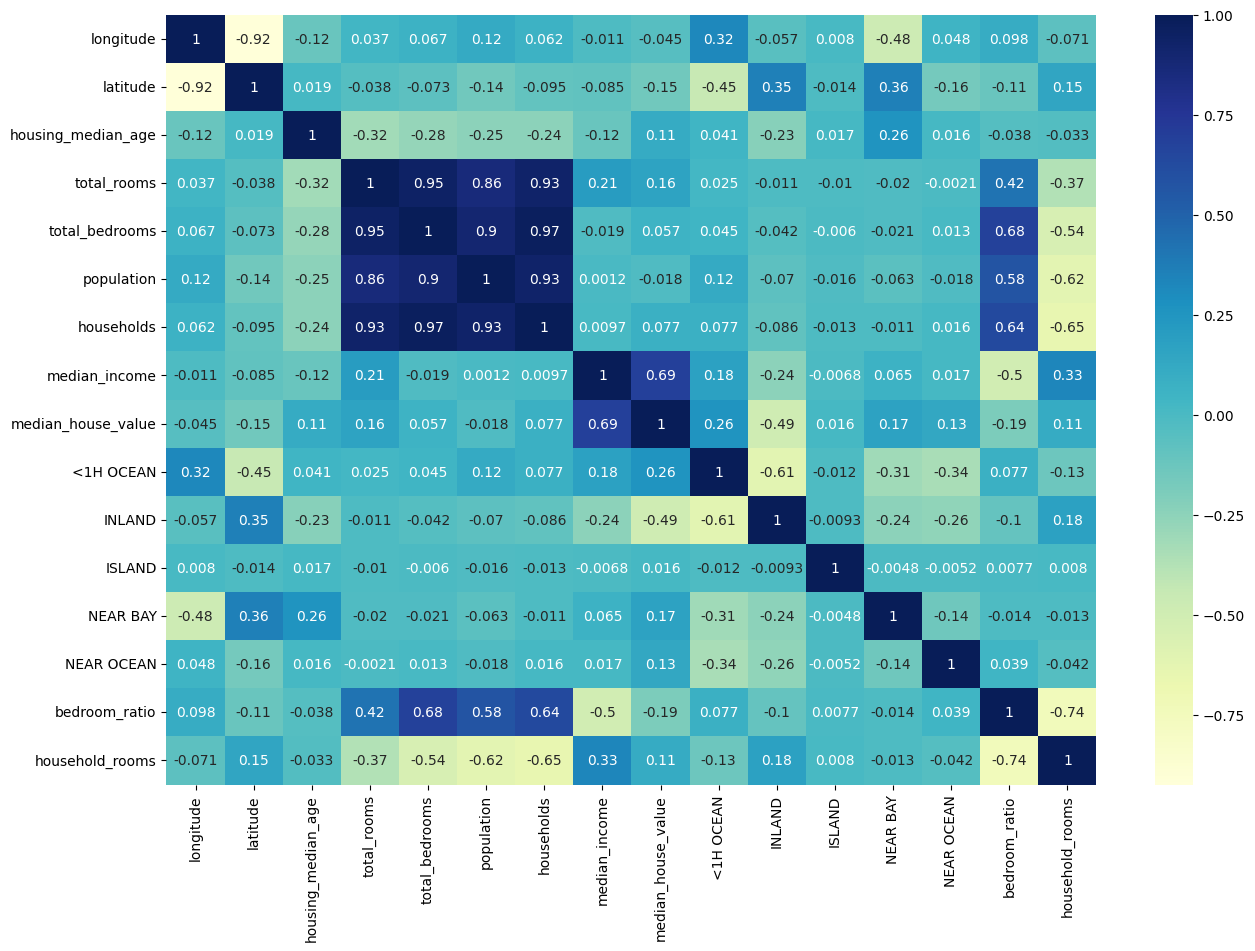

In [48]:
plt.figure(figsize=(15,10))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

# Wykorzystanie regresji liniowej
W tym momencie kiedy zestaw danych został już wystarczająco wyczerpany pora na przeprowadzenie estymacji - w tym celu najpierw dane zotaną poddane skalowaniu a dopiero potem wykorzystane przez regresję liniową.

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, Y_train = train_data.drop(["median_house_value"], axis=1), train_data["median_house_value"]
X_train_s = scaler.fit_transform(X_train)

reg = LinearRegression()
reg.fit(X_train_s, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[-58148.62,-60144.3 , 13637.34,..., 3594.54,-20413.2 , -3552.34]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.068e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,14
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](15,)","[279.67,204.14,167.06,..., 13.01, 5.14, 0. ]"


Teraz pora na przeprowadzenie testu - dane testowe tak samo jak dane treningowe trzeba odpowiednio przygotować (usunąć skośność wybranych kolumn), rozdzielić oraz dodać odpowiednie cechy i na końcu zeskalować.

In [52]:
test_data = X_test.join(Y_test)

test_data["total_rooms"] = np.log1p(test_data["total_rooms"])
test_data["total_bedrooms"] = np.log1p(test_data["total_bedrooms"])
test_data["population"] = np.log1p(test_data["population"])
test_data["households"] = np.log1p(test_data["households"])

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop(["ocean_proximity"], axis=1)

test_data["bedroom_ratio"] = test_data["total_bedrooms"] / test_data["total_rooms"]
test_data["household_rooms"] = test_data["total_rooms"] / test_data["households"]

In [53]:
X_test, Y_test = test_data.drop(["median_house_value"], axis=1), test_data["median_house_value"]
X_test_s = scaler.transform(X_test)

# Wyniki
Poniżej wykorzystano kilka różnych wskaźników w celu oceny skuteczności zastosowanego modelu.

In [54]:
reg.score(X_test_s, Y_test)

0.683697389088439

Wartość 0.68 mówi o ile ten model jest lepszy od modelu, który zawsze przewidywałby średnią cenę. 

In [65]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

Y_pred = reg.predict(X_test_s)
print(f"MAE:  {mean_absolute_error(Y_test, Y_pred):.0f} $")
print(f"RMSE: {root_mean_squared_error(Y_test, Y_pred):.0f} $")

MAE:  46865 $
RMSE: 64610 $


Wartość MAE (ang. Mean Absolute Error) mówi o ile średnio model myli się względem realnej ceny - w tym wypadku jest to ok. 47 tyś. dolarów.

Wartość RMSE (ang. Root Mean Squared Error) karze mocniej za duże błędy niż MAE - różnica między nimi (64k vs 46k) sugeruje że model sporadycznie myli się o znacznie więcej niż przeciętne 46k.

Text(0, 0.5, 'Predykcja')

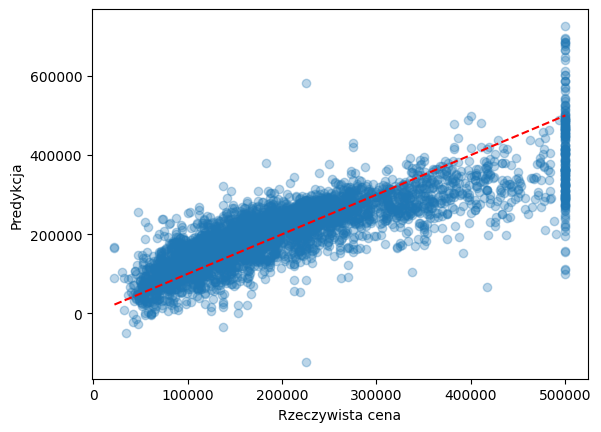

In [66]:
plt.scatter(Y_test, Y_pred, alpha=0.3)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel("Rzeczywista cena")
plt.ylabel("Predykcja")

Wykres wszystkich predykcji w stosunku do rzeczywistej ceny - kropki, które leżą idealnie na czerwonej lini to trafione predykcje.

<Axes: >

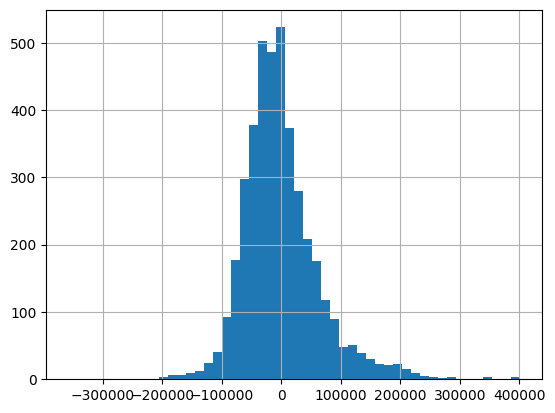

In [67]:
residuals = Y_test - Y_pred
residuals.hist(bins=50)

Na histogramie rozkładu reszt widać delikanty ogon w prawą stonę - oznacza to, że model niedoszacowuje wartości drogich domów. Wykres generalnie leży blisko zera, a więc nie ma systematycznego błędu, małe błędy zdarzają się czesto a duże rzadziej oraz myli się losowo w obie strony.

# Podsumowanie i wnioski

Podsumowując całościowo proces analizy i wykorzystania modelu został przeprowadzony w sposób prawidłowy. Model nie ma skłonności do powtarzalności w błędach, a jego skuteczność wynosi ok. 68% w stosunku do modelu zawsze przewidującego średnią cenę. Co więcej, wartości MAE to ok. 46 tyś. dolarów, a RMSE 64 tyś. dolarów co może oznaczać problem z pojawianiem się sporadycznych dużych błędów.

Regresja liniowa osiągnęła skuteczność 68% względem modelu bazowego, co wskazuje na umiarkowaną zdolność do estymacji cen. Głównym ograniczeniem jest liniowe założenie modelu - zależność między lokalizacją geograficzną a ceną nieruchomości ma charakter nieliniowy, czego regresja liniowa nie jest w stanie w pełni uchwycić, stąd widoczne niedoszacowanie wartości droższych nieruchomości.